In [1]:
import pandas as pd
import os
import numpy as np



In [2]:
df_template = pd.read_csv("./Alpha_Restrict.csv") 

In [3]:
df_TRA = pd.read_csv("./TRA_T.csv")
Alignment_df_Cols = df_TRA.columns[df_TRA.columns.isin(df_template["CDR3"])]

In [4]:
df_TRA_cols = df_TRA.columns.to_list()
df_TRA_cols[0] = "sample"
df_TRA.columns = df_TRA_cols
use_cols = df_TRA.columns[:2].tolist()
AR_df_TRA = df_TRA[use_cols+Alignment_df_Cols.tolist()]

In [5]:
df_TRA_sum = df_TRA[df_TRA.columns[2:]].sum(axis=1)

In [6]:
MAIT_CDR3s = df_template[df_template["Type"]=="MAIT"]["CDR3"].tolist()
iNKT_CDR3s = df_template[df_template["Type"]=="iNKT"]["CDR3"].tolist()

In [7]:
Profile = pd.DataFrame({"sample":AR_df_TRA["sample"],"category":AR_df_TRA["category"]})
Profile["MAIT_Sum"] = AR_df_TRA[AR_df_TRA.columns[AR_df_TRA.columns.isin(MAIT_CDR3s)]].sum(axis=1)
Profile["MAIT_Sum_log"] = np.log10(AR_df_TRA[AR_df_TRA.columns[AR_df_TRA.columns.isin(MAIT_CDR3s)]].sum(axis=1))
Profile["iNKT_Sum"] = AR_df_TRA[AR_df_TRA.columns[AR_df_TRA.columns.isin(iNKT_CDR3s)]].sum(axis=1)
Profile["iNKT_Sum_log"] = np.log10(AR_df_TRA[AR_df_TRA.columns[AR_df_TRA.columns.isin(iNKT_CDR3s)]].sum(axis=1))
Profile["MAIT_Frequency"] = Profile["MAIT_Sum"]/df_TRA_sum
Profile["iNKT_Frequency"] = Profile["iNKT_Sum"]/df_TRA_sum
custom_order = [r"healthy",r"patient"] 
Profile = Profile.sort_values(by='category', key=lambda x: x.map({name: i for i, name in enumerate(custom_order)}))

/home/hut/anaconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
Profile.to_csv("MAIT_INKT.csv",index=False)

/home/hut/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hut/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hut/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


<Axes: xlabel='category', ylabel='iNKT_Frequency'>

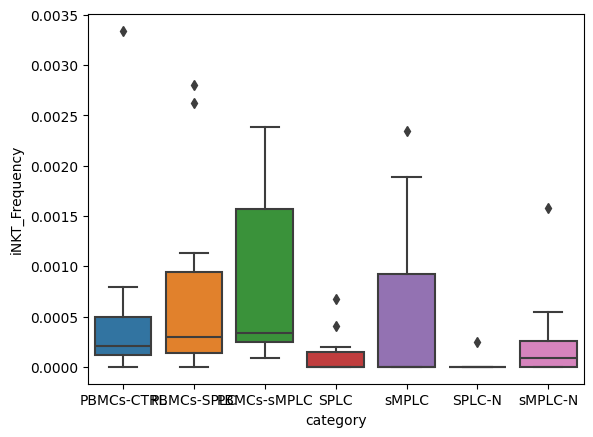

In [14]:
import seaborn as sns
sns.boxplot(Profile[Profile["category"]!="CBs"],x="category",y="iNKT_Frequency")

In [71]:
Profile.to_csv("AR.csv",index=False)

AttributeError: 'PathPatch' object has no attribute 'get_x'

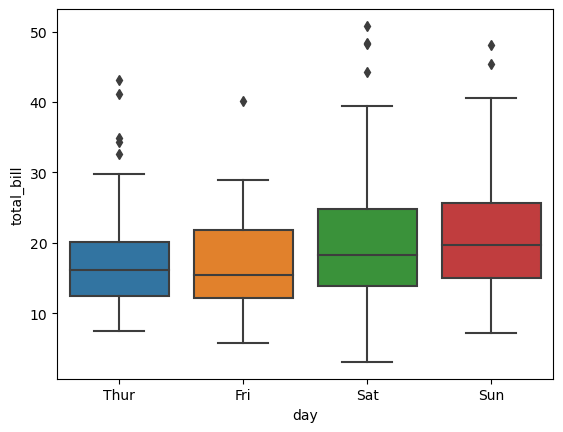

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# 示例数据
data = sns.load_dataset('tips')

# 绘制箱图
ax = sns.boxplot(x='day', y='total_bill', data=data)

# 执行 Mann-Whitney U 检验
result = mannwhitneyu(data[data['day'] == 'Fri']['total_bill'],
                      data[data['day'] == 'Sat']['total_bill'])

# 获取 P 值
p_value = result.pvalue

# 获取箱图的坐标信息
box_coords = [(box.get_x(), box.get_x() + box.get_width()) for box in ax.patches]

# 找到两个箱子的头顶位置
box_top_y = [box.get_y() + box.get_height() for box in ax.patches]

# 在两个箱子的头顶位置标注 P 值
plt.annotate(f'P-value = {p_value:.4f}', xy=(box_coords[0][0] + box_coords[0][1]) / 2, xytext=(box_coords[1][0] + box_coords[1][1]) / 2,
             ha='center', va='center', arrowprops=dict(arrowstyle='-', lw=1.5),
             fontsize=10, color='red')

# 显示图形
plt.show()
